In [1]:
!pip install -q transformers datasets accelerate peft bitsandbytes tqdm numpy evaluate huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 57.8 MB/s eta 0:00:00


In [2]:
# !pip install -q lime shap

In [4]:
from huggingface_hub import login
login()

In [15]:
# FastSHAP 데이터 준비 및 surrogate 모델 학습 템플릿

from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
import torch
import re
from itertools import combinations
import json
import pandas as pd1
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd

In [7]:
from transformers import BitsAndBytesConfig

bnb_cfg = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16
)

base_model = AutoModelForCausalLM.from_pretrained(
    "capston-team-5/finma-7b-4bit-quantized",
    device_map="auto",  # GPU/CPU 자동 할당
    quantization_config=bnb_cfg
)

model = PeftModel.from_pretrained(
    base_model,
    "capston-team-5/finma-7b-lora-regression-v1"
)

tokenizer = AutoTokenizer.from_pretrained("capston-team-5/finma-7b-lora-regression-v1")

model.eval()


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/transformers/quantizers/auto.py:222: UserWarning: You passed `quantization_config` or equivalent parameters to `from_pretrained` but the model you're loading already has a `quantization_config` attribute. The `quantization_config` from the model will be used.
  warnings.warn(warning_msg)


model.safetensors:   0%|          | 0.00/3.87G [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['pad_token_id']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['pad_token_id']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


...

tokenizer_config.json:   0%|          | 0.00/992 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.62M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(32000, 4096, padding_idx=31999)
        (layers): ModuleList(
          (0-31): 32 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=4096, out_features=4096, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=4096, out_features=32, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=32, out_features=4096, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
         

In [18]:
feature_names = ["date", "open", "high", "low", "close", "volume", "change"]

In [25]:
# Step 1: 입력 프롬프트
input_prompt = """
Using the context below, estimate the rate of change in the closing price of SK 하이닉스 on 2025-05-24.
Return the expected value of change as a decimal.

Context: date, open, high, low, close, volume, change.
2025-04-28, 55800, 55900, 55500, 55800, 9341518, 0.0000000000000000
2025-04-29, 55700, 56500, 55600, 55800, 10295518, 0.0000000000000000
2025-04-30, 55900, 56000, 55300, 55500, 13014189, -0.0053763440860215
2025-05-02, 55000, 55500, 54200, 54300, 22454204, -0.0216216216216216
2025-05-07, 54500, 55000, 54300, 54600, 17136991, 0.0055248618784531
2025-05-08, 55100, 55500, 54500, 54600, 16320532, 0.0000000000000000
2025-05-09, 54700, 55000, 54400, 54800, 7814322, 0.0036630036630036

Answer:
"""

# Step 1-1: Context 파싱
def extract_context_lines(input_prompt: str):
    lines = input_prompt.strip().split('\n')
    context_start = next(i for i, line in enumerate(lines) if line.startswith("Context:"))
    data_lines = lines[context_start + 1:]
    return data_lines

# Step 1-2: 특정 feature column masking

def mask_features_in_context(context_lines, masked_feature_indices):
    masked_lines = []
    for line in context_lines:
        values = line.split(", ")
        if len(values) != len(feature_names):
            print(f"[WARNING] Skipped malformed line: {line}")
            continue  # 또는 raise 에러로 명확히 할 수도 있음
        for idx in masked_feature_indices:
            values[idx] = "[MASK]"
        masked_lines.append(", ".join(values))
    return masked_lines


def make_column_masked_prompt(context_lines, masked_feature_indices):
    masked_context_lines = mask_features_in_context(context_lines, masked_feature_indices)
    header = "Context: date, open, high, low, close, volume, change."
    new_context = header + "\n" + "\n".join(masked_context_lines)
    new_prompt = (
        "Using the context below, estimate the rate of change in the closing price of SK\uc544\uc774\ub2c8\uc2a4 on 2025-05-24.\n"
        "Return the expected value of change as a decimal.\n\n"
        + new_context + "\n\nAnswer:"
    )
    return new_prompt

In [20]:
# Step 2: 마스킹 조합 생성 (column-level)
def generate_feature_masked_prompts(input_prompt, max_mask_count=2):
    total_features = len(feature_names)
    context_lines = extract_context_lines(input_prompt)
    all_prompts = []
    for r in range(1, max_mask_count + 1):
        for masked_indices in combinations(range(total_features), r):
            masked_prompt = make_column_masked_prompt(context_lines, masked_indices)
            all_prompts.append((masked_prompt, masked_indices))
    return all_prompts

# Step 3: FinMA 예측 함수 (간소화 버전)
def get_finma_prediction(prompt, model, tokenizer):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=10)
    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)
    matches = re.findall(r"[-+]?\d*\.\d+|\d+", decoded)
    if matches:
        return float(matches[-1])
    raise ValueError("\uc608\ucc28\uac12 \ucd94\ucd9c \uc2e4\ud328: " + decoded)

# Step 4: delta 계산 (column-level masking)
def compute_column_deltas(input_prompt, all_prompts, model, tokenizer):
    n_features = len(feature_names)
    f_x = get_finma_prediction(input_prompt, model, tokenizer)
    results = []
    for masked_prompt, mask_indices in all_prompts:
        f_xs = get_finma_prediction(masked_prompt, model, tokenizer)
        delta = round(f_x - f_xs, 6)
        mask_vector = [1 if i in mask_indices else 0 for i in range(n_features)]
        results.append({"mask": mask_vector, "delta": delta})
    return results

# Step 5: surrogate 학습 (Ridge)
def train_surrogate(results):
    X = [r["mask"] for r in results]
    y = [r["delta"] for r in results]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = Ridge()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f"Surrogate Test MSE: {mse:.6f}")
    return model

# Step 6: 모델 저장
def save_surrogate_model(model, path="surrogate_model.pkl"):
    joblib.dump(model, path)
    print(f"Surrogate model saved to {path}")

# Step 7: 시각화
def plot_feature_importance(surrogate_model):
    coefs = surrogate_model.coef_
    plt.figure(figsize=(10, 4))
    plt.bar(feature_names, coefs)
    plt.xlabel("Feature")
    plt.ylabel("Estimated SHAP value (importance)")
    plt.title("Surrogate Feature Importance")
    plt.grid(True)
    plt.show()


In [17]:
import joblib

In [21]:
# 예측값 출력
print(get_finma_prediction(input_prompt, model, tokenizer))

2.0


In [26]:
all_prompts = generate_feature_masked_prompts(input_prompt, max_mask_count=2)
results = compute_column_deltas(input_prompt, all_prompts, model, tokenizer)

[WARNING] Skipped malformed line: 
[WARNING] Skipped malformed line: Answer:
[WARNING] Skipped malformed line: 
[WARNING] Skipped malformed line: Answer:
[WARNING] Skipped malformed line: 
[WARNING] Skipped malformed line: Answer:
[WARNING] Skipped malformed line: 
[WARNING] Skipped malformed line: Answer:
[WARNING] Skipped malformed line: 
[WARNING] Skipped malformed line: Answer:
[WARNING] Skipped malformed line: 
[WARNING] Skipped malformed line: Answer:
[WARNING] Skipped malformed line: 
[WARNING] Skipped malformed line: Answer:
[WARNING] Skipped malformed line: 
[WARNING] Skipped malformed line: Answer:
[WARNING] Skipped malformed line: 
[WARNING] Skipped malformed line: Answer:
[WARNING] Skipped malformed line: 
[WARNING] Skipped malformed line: Answer:
[WARNING] Skipped malformed line: 
[WARNING] Skipped malformed line: Answer:
[WARNING] Skipped malformed line: 
[WARNING] Skipped malformed line: Answer:
[WARNING] Skipped malformed line: 
[WARNING] Skipped malformed line: Answer:

In [27]:
surrogate = train_surrogate(results)
save_surrogate_model(surrogate)


Surrogate Test MSE: 0.411993
Surrogate model saved to surrogate_model.pkl


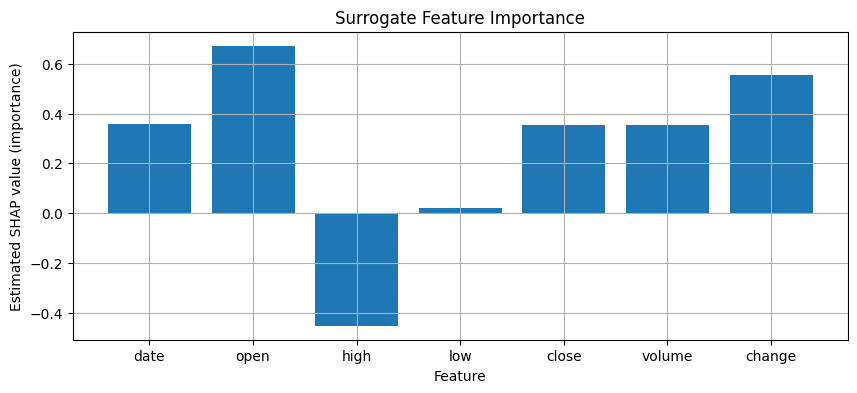

In [28]:
plot_feature_importance(surrogate)